## Сессия 3 - Группировка и агрегация данных

In [3]:
import pandas as pd
df_orders = pd.read_csv('data/orders.csv', sep = ';')
df_customers = pd.read_csv('data/customers.csv', sep = ';')
df_payments = pd.read_csv('data/payments.csv', sep = ';')


1.1 Чистка и подготовка данных orders

In [5]:
df_orders['is_delivered'] = df_orders['order_delivered_customer_date'].notna()
print(df_orders['is_delivered'].value_counts())
print(f'Исключено из датасета: {df_orders['is_delivered'].value_counts(normalize = True)[False] * 100.:2f}%. Данные исключены в связи с тем, что данные заказы не были когда либо доставлены')
print()
orders = df_orders[df_orders['is_delivered']].copy().dropna()
columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in columns:
    orders[col] = pd.to_datetime(orders[col])
print(orders.info())

is_delivered
True     96476
False     2965
Name: count, dtype: int64
Исключено из датасета: 2.981668%. Данные исключены в связи с тем, что данные заказы не были когда либо доставлены

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
 8   is_delivered                   96461 n

1.2 Подготовка данных в customers. Критичные поля - customer_id, customer_unique_id


In [7]:
## Повешен флаг для подтверждения только тех пользователей, имеющих корректные учетнные данные
df_customers['confirm'] = (df_customers['customer_id'].notna()) & (df_customers['customer_unique_id'].notna())
## Заполнение возмодных нулевых значений на 'unknown'
df_customers[['customer_city', 'customer_state']] = (
    df_customers[['customer_city', 'customer_state']].fillna('unknown')
)
print(f"Всего подтвержденных пользователей: {len(df_customers[df_customers['confirm']])}")
print()
counts = len(df_customers) - df_customers['confirm'].sum()
print(f"Всего пользователей vs подтвержденных: {len(df_customers)} / {df_customers['confirm'].sum()}, разница: {counts}")
print()
if counts > 0:
    print('Необходима очистка от нулевых значений')
    customers = df_customers[df_customers['conirm']].copy()
    print(customers.info())
else:
    print('Нулевые значения отсутствуют')
    customers = df_customers.copy()
    print(customers.info())

Всего подтвержденных пользователей: 99441

Всего пользователей vs подтвержденных: 99441 / 99441, разница: 0

Нулевые значения отсутствуют
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
 5   confirm                   99441 non-null  bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 3.9+ MB
None


1.3 Подготовка и очистка данных payments

In [9]:
## Вешаем флаг и убираем возможные нулевые значения в полях
df_payments['conf_&_paid'] = (df_payments['order_id'].notna()) & (df_payments['payment_sequential'].notna()) & (df_payments['payment_value'].ne(0)) & (df_payments['payment_value'].notna()) 
df_payments['payment_type'].fillna('unknown')
counts = len(df_payments) - df_payments['conf_&_paid'].sum()
print(f"Неподтвержденные vs подтвержденные: {len(df_payments)} / {df_payments['conf_&_paid'].sum()}, разница: {counts}")
print()
if counts > 0:
    print('Необходима очистка от нулевых значений')
    payments = df_payments[df_payments['conf_&_paid']].copy()
    print(payments.info())
else:
    print('Нулевые значения отсутствуют')
    payments = df_payments.copy()
    print(customers.info())

Неподтвержденные vs подтвержденные: 103886 / 103877, разница: 9

Необходима очистка от нулевых значений
<class 'pandas.core.frame.DataFrame'>
Index: 103877 entries, 0 to 103885
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103877 non-null  object 
 1   payment_sequential    103877 non-null  int64  
 2   payment_type          103877 non-null  object 
 3   payment_installments  103877 non-null  int64  
 4   payment_value         103877 non-null  float64
 5   conf_&_paid           103877 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 4.9+ MB
None


Объединение и подсчет **GMV** по месяцам

      Месяц     Выручка
0   2017-01   127430.74
1   2017-02   269458.98
2   2017-03   414369.39
3   2017-04   390952.18
4   2017-05   566872.73
5   2017-06   490225.60
6   2017-07   566403.93
7   2017-08   646000.61
8   2017-09   700976.01
9   2017-10   751140.27
10  2017-11  1153393.22
11  2017-12   843199.17
12  2018-01  1078606.86
13  2018-02   966554.97
14  2018-03  1120678.00
15  2018-04  1132933.95
16  2018-05  1128836.69
17  2018-06  1011561.35
18  2018-07  1027383.10
19  2018-08   985414.28


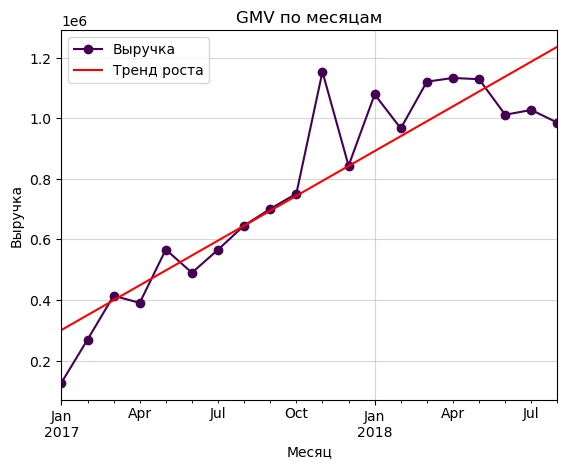

In [62]:
import numpy as np
import matplotlib.pyplot as plt
combine_df = pd.merge(orders, payments, on = 'order_id', how = 'inner')
# На основе выполненных ранее SQL запросов известесно, что измерениям подлежит период 2017-01 - 2018-08. Остальные месяцы в датасете содержат неполные значения
start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (combine_df['order_purchase_timestamp'] >= start_date) & (combine_df['order_purchase_timestamp'] <= end_date)
final_combine = combine_df[date_mask].copy()

total_orders = final_combine.groupby(['order_id', 'order_purchase_timestamp'])['payment_value'].sum().reset_index()
total_orders.columns = ['order_id', 'order_purchase_timestamp', 'Выручка']

total_orders['Месяц'] = total_orders['order_purchase_timestamp'].dt.to_period('M')
gmv_month = total_orders.groupby('Месяц')['Выручка'].sum().reset_index()

print(gmv_month)
gmv_month.to_csv('data/gmv_per_month.csv', index = False, encoding = 'utf-8', sep = ';')
ax = gmv_month.plot(x = 'Месяц', y = 'Выручка', cmap = 'viridis', kind = 'line', marker = 'o', label = 'Выручка')
z = np.polyfit(range(len(gmv_month)), gmv_month['Выручка'], 1)
p = np.poly1d(z)
ax.plot(gmv_month['Месяц'], p(range(len(gmv_month))), color = 'red', label = 'Тренд роста')
plt.title('GMV по месяцам'),
plt.xlabel('Месяц'),
plt.ylabel('Выручка'),
plt.legend(),
plt.grid(True, alpha = 0.5)
plt.show()




**Инсайт:** Опираясь на построенный график GMV по месяцам хорошо видно, что площадка имела планомерное развитие, с периодическими падениями. Пик выручки был достигнут в ноябре 2017 года, после чего рост выручки компании несколько замедлился и пошел, возможно, на кратковременный спад

In [34]:
final_combine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100447 entries, 0 to 100734
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       100447 non-null  object        
 1   customer_id                    100447 non-null  object        
 2   order_status                   100447 non-null  object        
 3   order_purchase_timestamp       100447 non-null  datetime64[ns]
 4   order_approved_at              100447 non-null  datetime64[ns]
 5   order_delivered_carrier_date   100447 non-null  datetime64[ns]
 6   order_delivered_customer_date  100447 non-null  datetime64[ns]
 7   order_estimated_delivery_date  100447 non-null  datetime64[ns]
 8   is_delivered                   100447 non-null  bool          
 9   payment_sequential             100447 non-null  int64         
 10  payment_type                   100447 non-null  object        
 11  payme

**Рассчет AOV, ARPU**

      Месяц    arpu     aov
0   2017-01  177.98  170.36
1   2017-02  166.54  164.20
2   2017-03  165.22  162.75
3   2017-04  171.92  169.76
4   2017-05  162.99  159.91
5   2017-06  159.37  156.37
6   2017-07  148.98  146.28
7   2017-08  157.02  154.07
8   2017-09  171.72  168.95
9   2017-10  170.06  167.74
10  2017-11  160.59  158.26
11  2017-12  154.72  152.95
12  2018-01  154.66  152.58
13  2018-02  151.00  147.43
14  2018-03  162.09  160.03
15  2018-04  167.99  166.66
16  2018-05  168.66  167.26
17  2018-06  166.98  165.94
18  2018-07  168.51  166.89
19  2018-08  156.17  155.16


<Axes: title={'center': 'Средний чек по месяцам'}, xlabel='Месяц'>

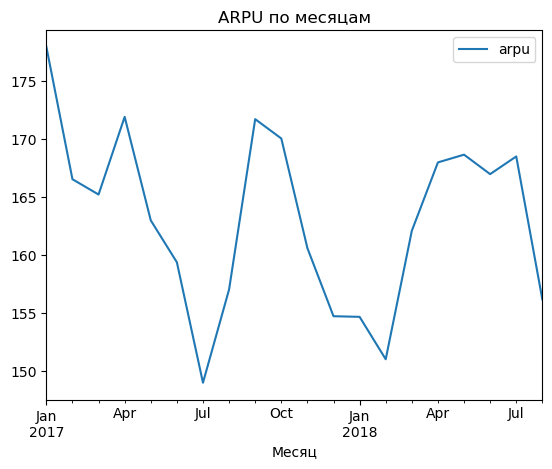

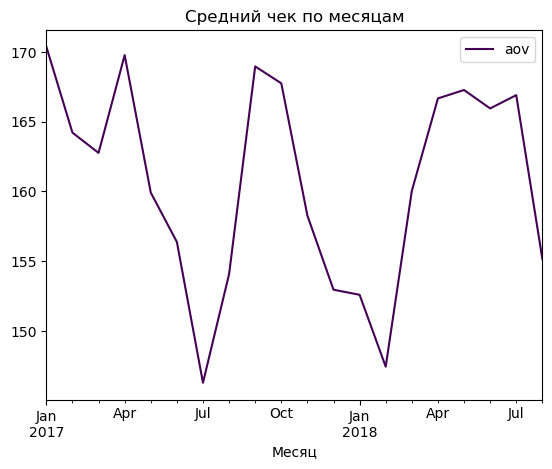

In [63]:
comb_with_customers = pd.merge(final_combine, customers, on = 'customer_id', how = 'inner')
orders_total = comb_with_customers.groupby(['customer_unique_id', 'order_id', 'order_purchase_timestamp'])['payment_value'].sum().reset_index()
orders_total.columns = ['customer_unique_id', 'order_id', 'order_purchase_timestamp', 'Выручка']
orders_total['Месяц'] = orders_total['order_purchase_timestamp'].dt.to_period('M')
stats = orders_total.groupby('Месяц').agg(rev = ('Выручка', 'sum'), orders = ('order_id', 'count'),  users_count = ('customer_unique_id', 'nunique')).reset_index()
stats['arpu'] = stats['rev'] / stats['users_count']
stats['aov'] = stats['rev'] / stats['orders']
print(stats[['Месяц', 'arpu', 'aov']].round(2))
stats[['Месяц', 'arpu', 'aov']].to_csv('data/arpu_aov.csv', index = False, encoding = 'utf-8', sep = ';')
stats.plot(x = 'Месяц', y = 'arpu', kind = 'line', title = 'ARPU по месяцам')
stats.plot(x = 'Месяц', y = 'aov', kind = 'line', cmap = 'viridis', title = 'Средний чек по месяцам')


**Инсайт**: 
- 1 Компания развивается экстенсивно, так как видно, что при стремительном росте выручки средний чек и средняя выручка на покупателя остаются на одном уровне. Для дальнейшего роста рекомендуется использовать Retetion Marketing, так как стоимость привлечения растет и в скором времени бизнес упрется в потолок, что приведет к замедлению выручки бизнеса или даже остановке роста.
- 2 Оба графика почти идентичны и отражают одну картину, которая говорит о том, что покупатели приходят разово, после чего не возвращаются. На e-commerce площадке olist широко представлена электроника, которую покупают редко. При этом, бизнесу не стоит надеяться на то, что клиент станет регулярным покупателем. В связи с этим, бизнесу всячески необходимо максимизировать прибыль с первой сделки, так как второй раз он может не вернуться (И в основном не возвращается, судя по графикам, но это уже проблема Retetion)
- 3 Наблюдается сезонность. Падение средних показателей чека и среднего показателя выручки на человека связано с тем, что традиционно летом люди тратят меньше денег. Также, наблюдаются провалы после новогдних праздников, что говорит о том, что люди потратили средства перед праздниками и склонны экономить в первые 2 месяца года. Для выравнивания показателей рекомендуется проводить летние и предновогодние акции привлекая покупателей
- 4 Компания растет засчет реального объема, а не засчет привлечения дешевых клиентов, что добавляет устойчивости компании


**Итоговый вывод (Анализ юнит экономики 2017-2018)**:
- 1. Выручка компании растет почти каждый месяц, при этом показатели ARPU и AOV стагнирует, что говорит о том, что компания плохо стимулирует повторные покупки
- 2. Наблюдается системное падение метрик летом, а также в январе и феврале. Необходимо скорректировать медиаплан на эти периоды
- 3. Рекомендуется разработать план по удержанию клиентов и мотивированию их к новым покупкам  

**4. Рассчет топ-категорий по продажам**

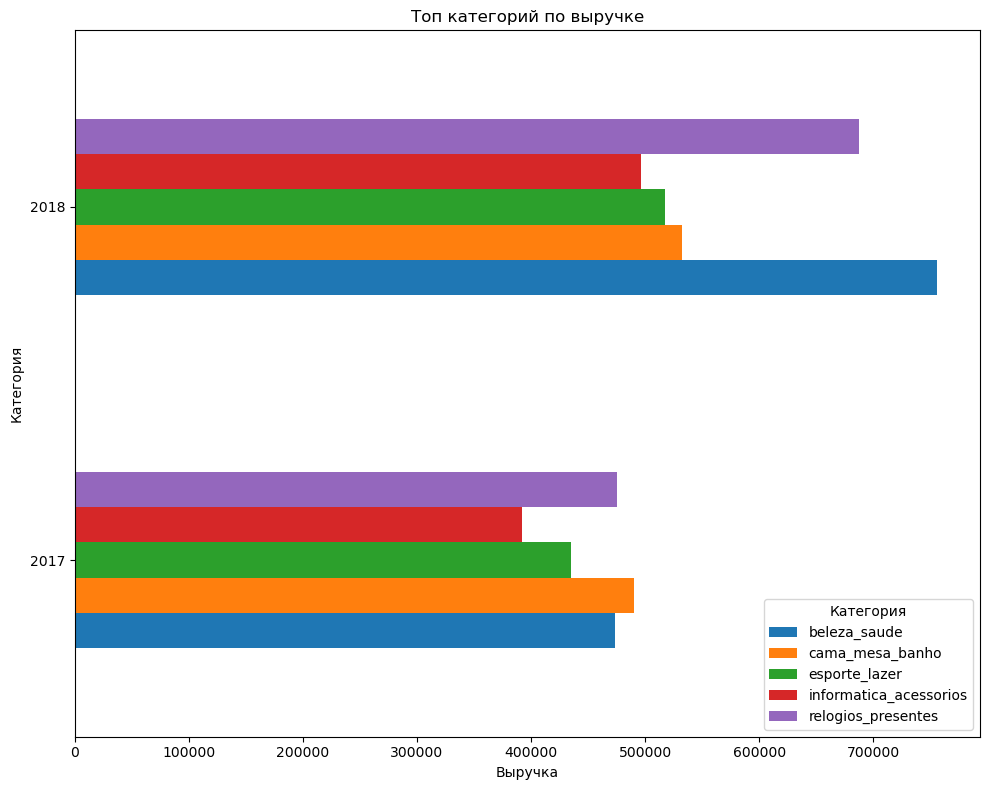

In [64]:
items = pd.read_csv('data/items.csv', sep = ';')
products = pd.read_csv('data/products.csv', sep = ';')

orders_products = pd.merge(orders, items, on = 'order_id', how = 'inner')
orders_products = pd.merge(orders_products, products, on = 'product_id', how = 'inner')

orders_products['product_category_name'] = orders_products['product_category_name'].fillna('unknown')
orders_products['year'] = orders_products['order_purchase_timestamp'].dt.year

start_date = '2017-01-01'
end_date = '2018-08-31'

date_mask = (orders_products['order_purchase_timestamp'] >= start_date) & (orders_products['order_purchase_timestamp'] <= end_date)
final_ord_prod = orders_products[date_mask].copy()

category_rev = final_ord_prod.groupby(['year', 'product_category_name'])['price'].sum().reset_index()
category_rev.columns = ['Год', 'Категория', 'Выручка']

top_categories = category_rev.sort_values('Выручка', ascending = False).groupby('Год').head(5)
pivot_cats = top_categories.pivot(index = 'Год', columns = 'Категория', values = 'Выручка').fillna(0)
pivot_cats.to_csv('data/top_categories.csv', index = True, encoding = 'utf-8', sep = ';')

pivot_cats.plot(kind = 'barh', figsize = (10, 8), title = 'Топ категорий по выручке')
plt.xlabel('Выручка')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

**Инсайт:** Компания растет засчет планомерного увеличения продаж по всем ооповым категориям. Главной категорией является красота и здоровье. Данную категорию нужно укреплять. В 2018 году наибольший рост, помимо категории "Красота и здоровье" показала категория "Часы и подарки". Для дальнейшего роста необходимо направить в эту категорию маркетинговые и финансовые ресурсы для дальнейшего развития.
